# H6 — Difference Between Conditions

Compare: `both_item_task` vs `task_only` vs `item_only`.

We test condition differences for REC and LDI using simple independent t-tests.
Holm p-value correction is applied within each metric (required here).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'C:\Users\Satyajit\Desktop\BRSM EXP\DATA\compiled_preprocessed.csv')
df['boundary_position'] = pd.Categorical(df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

In [2]:
def p_resp(data, trial_type, response, boundary=None):
    x = data[data['trial_type'] == trial_type]
    if boundary is not None:
        x = x[x['boundary_position'] == boundary]
    if x.empty:
        return np.nan
    return (x['user_response'] == response).mean()

rows = []
for (pid, cond), sub in df.groupby(['participant_id', 'condition']):
    foil_old = p_resp(sub, 'Foil', 'Target')
    foil_sim = p_resp(sub, 'Foil', 'Lure')
    rec_vals, ldi_vals = [], []
    for pos in ['Pre', 'Mid', 'Post']:
        rec_vals.append(p_resp(sub, 'Target', 'Target', pos) - foil_old)
        ldi_vals.append(p_resp(sub, 'Lure', 'Lure', pos) - foil_sim)
    rows.append({
        'participant_id': pid,
        'condition': cond,
        'REC': np.nanmean(rec_vals),
        'LDI': np.nanmean(ldi_vals)
    })

pm = pd.DataFrame(rows)
display(pm.groupby('condition')[['REC', 'LDI']].mean())

,REC,LDI
condition,,
both_item_task,0.602041,0.270408
item_only,0.633929,0.319048
task_only,0.595912,0.380503


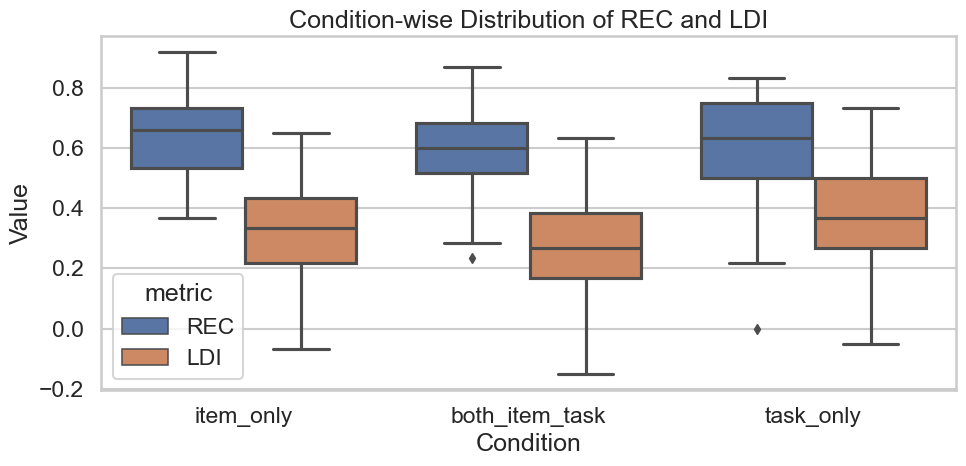

In [3]:
# Visualization: condition-wise distributions for REC and LDI
long_pm = pm.melt(id_vars=['participant_id', 'condition'], value_vars=['REC', 'LDI'], var_name='metric', value_name='value')
plt.figure(figsize=(10, 5))
sns.boxplot(data=long_pm, x='condition', y='value', hue='metric')
plt.title('Condition-wise Distribution of REC and LDI')
plt.xlabel('Condition')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [4]:
pairs = [
    ('both_item_task', 'task_only'),
    ('both_item_task', 'item_only'),
    ('task_only', 'item_only')
]

all_rows = []
for metric in ['REC', 'LDI']:
    temp = []
    for c1, c2 in pairs:
        x1 = pm.loc[pm['condition'] == c1, metric].dropna()
        x2 = pm.loc[pm['condition'] == c2, metric].dropna()
        test = ttest_ind(x1, x2, equal_var=False)
        temp.append({
            'metric': metric,
            'comparison': f'{c1} vs {c2}',
            'mean_diff': x1.mean() - x2.mean(),
            't_stat': test.statistic,
            'p_raw': test.pvalue
        })

    p_adj = multipletests([r['p_raw'] for r in temp], method='holm')[1]
    for r, pa in zip(temp, p_adj):
        r['p_adj_holm'] = pa
        r['different (adj p<.05)'] = pa < 0.05
        all_rows.append(r)

result_df = pd.DataFrame(all_rows)
display(result_df.sort_values(['metric', 'comparison']))

,metric,comparison,mean_diff,t_stat,p_raw,p_adj_holm,different (adj p<.05)
4,LDI,both_item_task vs item_only,-0.048639,-1.432211,0.155208,0.155208,False
3,LDI,both_item_task vs task_only,-0.110095,-3.044800,0.002976,0.008929,True
5,LDI,task_only vs item_only,0.061456,1.789435,0.076445,0.152890,False
1,REC,both_item_task vs item_only,-0.031888,-1.121226,0.264802,0.691121,False
0,REC,both_item_task vs task_only,0.006129,0.197466,0.843873,0.843873,False
2,REC,task_only vs item_only,-0.038017,-1.206503,0.230374,0.691121,False


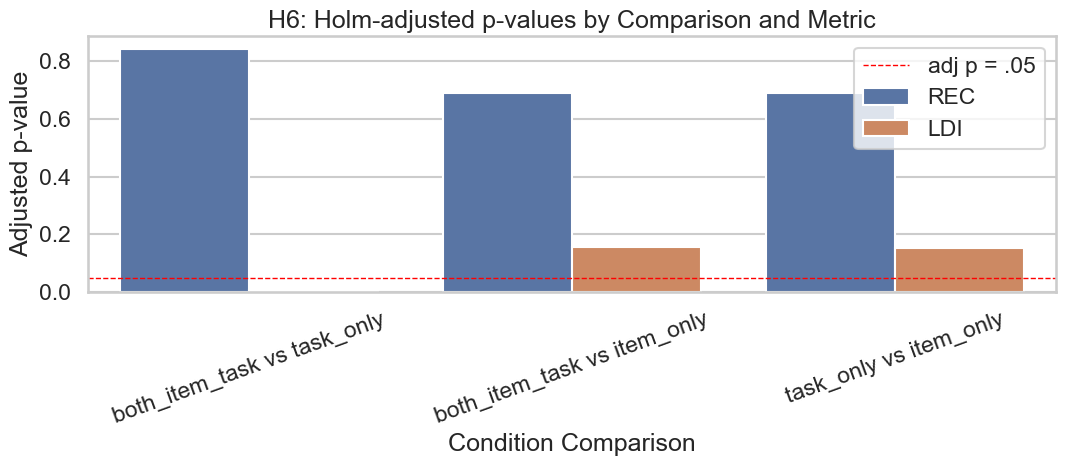

In [5]:
# Visualization: adjusted p-values (Holm) for condition differences
p_plot = result_df.copy()
plt.figure(figsize=(11, 5))
sns.barplot(data=p_plot, x='comparison', y='p_adj_holm', hue='metric')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='adj p = .05')
plt.title('H6: Holm-adjusted p-values by Comparison and Metric')
plt.xlabel('Condition Comparison')
plt.ylabel('Adjusted p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()